# Aprendizaje No Supervisado: Reducción de dimensionalidad.

## Introducción
Los métodos de reducción de dimensionalidad son técnicas estadísticas que mapean el conjunto de los datos a subespacios derivados del espacio original, de menor dimensión, que permiten hacer una descripción de los datos a un menor costo.

Estas técnicas cobran importancia ya que muchos algoritmos de diversos campos tales como análisis numérico, aprendizaje automático o minería de datos suelen degradar su rendimiento cuando se usan con datos de alta dimensionalidad. En los casos extemos, el algoritmo deja de ser útil para el fin que fue diseñado. La maldición de la dimensión, se refiere a los diversos fenómenos que surgen al analizar y organizar datos de espacios de múltiples dimensiones.

## Análisis de Componentes Principales (PCA)   

El *análisis de componentes principales(PCA)* es un método estadístico que permite simplificar la complejidad de espacios muestrales con muchas dimensiones a la vez que conserva su información.    

Supóngase que existe una muestra con $n$ individuos cada uno con $p$ variables $(𝑋_1,𝑋_2,…,𝑋_𝑝)$, es decir, el espacio muestral tiene $𝑝$ dimensiones.    
PCA permite encontrar un número de factores subyacentes $(𝑧<𝑝)$ que explican, aproximadamente, lo mismo que las $𝑝$ variables originales.    

Donde antes se necesitaban $𝑝$ valores para caracterizar a cada individuo, ahora bastan $𝑧$ valores. Cada una de estas $𝑧$ nuevas variables recibe el nombre de ***componente principal***.

### Interpretación geométrica de las componentes principales.    

Una forma intuitiva de entender el proceso de PCA consiste en interpretar las componentes principales desde un punto de vista geométrico.    

Supóngase un conjunto de observaciones para las que se dispone de dos variables $(𝑋_1,𝑋_2)$.     

El vector que define la primera componente principal $(𝑍_1)$ sigue la dirección en la que las observaciones varían más (linea roja). La proyección de cada observación sobre esa dirección equivale al valor de la primera componente para dicha observación.   

<img src="./img/interpretacion1.jpeg">

La segunda componente $(𝑍_2)$ sigue la segunda dirección en la que los datos muestran mayor varianza y que no está correlacionada con la primera componente.    
La condición de no correlación entre componentes principales equivale a decir que sus direcciones son perpendiculares.   

<img src="./img/interpretacion2.jpeg">

### Cálculo de las componentes principales.   

Cada componente principal $(𝑍_𝑖)$ se obtiene por combinación lineal de las variables originales. Se pueden entender como nuevas variables obtenidas al combinar de una determinada forma las variables originales.    

La primera componente principal de un grupo de variables $(𝑋_1,𝑋_2,…,𝑋_𝑝)$ es la combinación lineal normalizada de dichas variables que tiene mayor varianza:
$$𝑍_1=𝜙_{11} 𝑋_1 + 𝜙_{21} 𝑋_2 +⋯+ 𝜙_{𝑝1} 𝑋_𝑝$$

Los términos $𝜙_{11},…,𝜙_{1𝑝}$ reciben en el nombre de pesos y son los que definen a la componente. Se pueden interpretar como el *peso o importancia que tiene cada variable en cada componente* y, por lo tanto, *ayudan a conocer que tipo de información recoge cada una de las componentes*.



Dado un conjunt de datos $𝑋$ con $𝑛$ observaciones y $𝑝$ variables, el proceso a seguir para calcular la primera componente principal es:

- **Centralización de las variables**: se resta a cada valor la media de la variable a la que pertenece. Con esto se consigue que todas las variables tengan media cero.

- **Problema de optimización**: se resuelve el problema de optimización para encontrar el valor de los pesos con los que se maximiza la varianza. Una forma de resolver esta optimización es mediante el cálculo de evalores y vectores propios de la matriz de covarianza.

Una vez calculada la primera componente $(𝑍_1)$ se calcula la segunda $(𝑍_2)$ repitiendo el mismo proceso, pero añadiendo la condición de que la combinación lineal no pude estar correlacionada con la primera componente. Esto equivale a decir que $𝑍_1$ y $𝑍_2$ tienen que ser perpendiculares.    

EL proceso se repite de forma iterativa hasta calcular todas las posibles componentes $(min(𝑛−1,𝑝))$ o hasta que se decida detener el proceso.    

El orden de importancia de las componentes viene dado por la magnitud del valor propio asociado a cada vector propio.

### Escalado de las variables.   

El proceso de PCA identifica aquellas direcciones en las que la varianza es mayor. Como la varianza de una variable se mide en su misma escala elevada al cuadrado, si antes de calcular las componentes no se estandarizan todas las variables, aquellas variables cuya escala sea mayor dominarán al resto. De ahí que sea recomendable estandarizar siempre los datos.

### Influencia de outliers.   

Al trabajar con varianzas, el método PCA es altamente sensible a outliers, por lo que es altamente recomendable estudiar si los hay. La detección de valores atípicos con respecto a una determinada dimensión es algo relativamente sencillo de hacer mediante comprobaciones gráficas.    
Sin embargo, cuando se trata con múltiples dimensiones el proceso se complica. Por ejemplo, considérese un hombre que mide 2 metros y pesa 50 𝑘𝑔. Ninguno de los dos valores es atípico de forma individual, pero en conjunto se trataría de un caso muy excepcional.

### Número óptimo de componentes principales.   

Por lo general, dada una matriz de datos de dimensiones $𝑛×𝑝$, el número de componentes principales que se pueden calcular es como máximo de $𝑛−1$ o $𝑝$ (el menor de los dos valores es el limitante).    
Sin embargo, siendo el objetivo del PCA reducir la dimensionalidad, suelen ser de interés utilizar el número mínimo de componentes que resultan suficientes para explicar los datos.    
No existe una respuesta o método único que permita identificar cual es el número óptimo de componentes principales a utilizar.     
Una forma de proceder muy extendida consiste en evaluar la proporción de varianza explicada acumulada y seleccionar el número de componentes mínimo a partir del cual el incremento deja de ser sustancial.   

<img src="./img/codoPCA.jpeg">

## Ejemplo de PCA en lenguaje R

### EDA inicial

In [1]:
library(ggplot2)
library(cowplot)

theme_set(theme_bw(base_size = 12)) # Colocamos por defecto el tema de ggplot2

In [2]:
library(dplyr)
library(grid)


Adjuntando el paquete: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [3]:
data(iris)
head(iris, 5)

  Sepal.Length Sepal.Width Petal.Length Petal.Width Species
1          5.1         3.5          1.4         0.2  setosa
2          4.9         3.0          1.4         0.2  setosa
3          4.7         3.2          1.3         0.2  setosa
4          4.6         3.1          1.5         0.2  setosa
5          5.0         3.6          1.4         0.2  setosa

In [4]:
summary(iris)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

In [ ]:
cor(iris[,1:4]) # Matriz de correlación entre las variables numéricas 

             Sepal.Length Sepal.Width Petal.Length Petal.Width
Sepal.Length    1.0000000  -0.1175698    0.8717538   0.8179411
Sepal.Width    -0.1175698   1.0000000   -0.4284401  -0.3661259
Petal.Length    0.8717538  -0.4284401    1.0000000   0.9628654
Petal.Width     0.8179411  -0.3661259    0.9628654   1.0000000

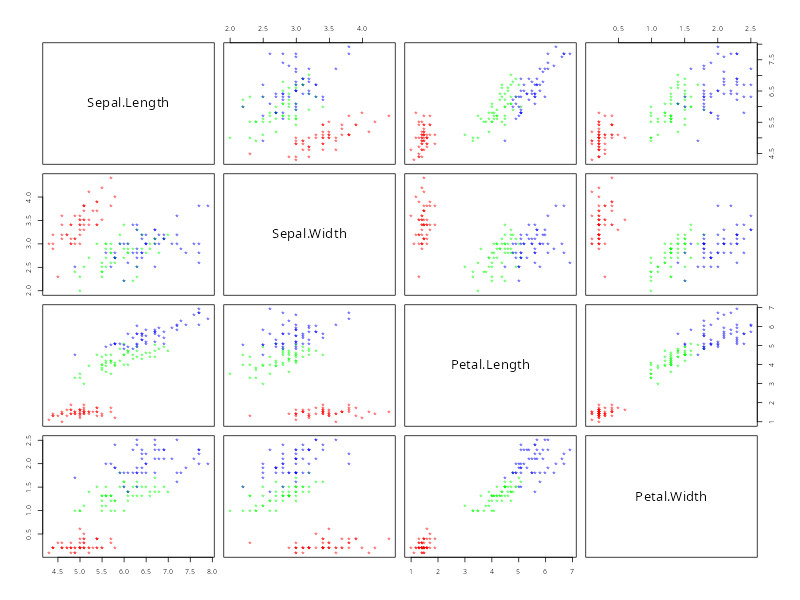

In [ ]:
plot(iris[,1:4], pch='*',col=c("red", "green", "blue")[unclass(iris[,5])]) # Gráfico de dispersión entre las variables numéricas, coloreando por especie

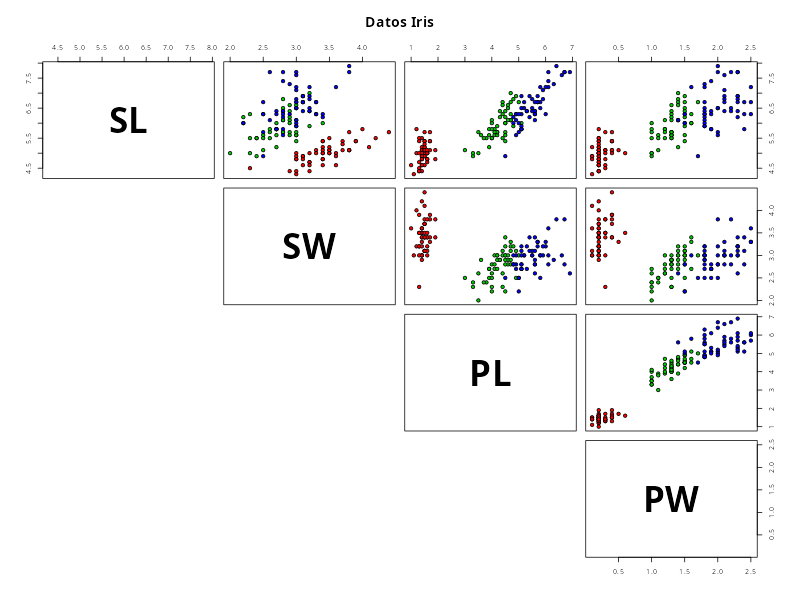

In [8]:
pairs(iris[1:4], main = "Datos Iris", pch = 21, bg = c("red", "green3", "blue")[unclass(iris$Species)], 
lower.panel=NULL, labels=c("SL","SW","PL","PW"), font.labels=2, cex.labels=4.5) # Gráfico de pares entre las variables numéricas, coloreando por especie

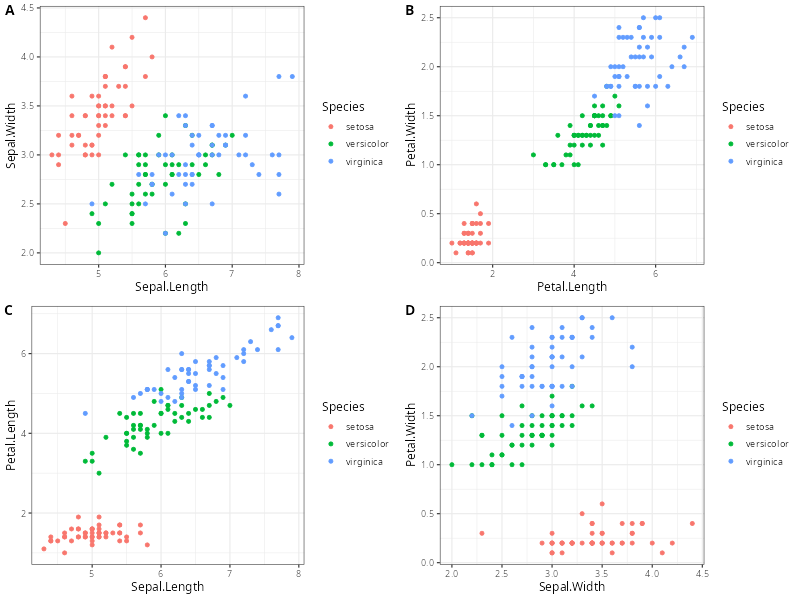

In [9]:
# 
p1 <- ggplot(iris, aes(x=Sepal.Length, y=Sepal.Width, color=Species)) + geom_point()
p2 <- ggplot(iris, aes(x=Petal.Length, y=Petal.Width, color=Species)) + geom_point()
p3 <- ggplot(iris, aes(x=Sepal.Length, y=Petal.Length, color=Species)) + geom_point()
p4 <- ggplot(iris, aes(x=Sepal.Width, y=Petal.Width, color=Species)) + geom_point()
plot_grid(p1, p2, p3, p4, labels = "AUTO")

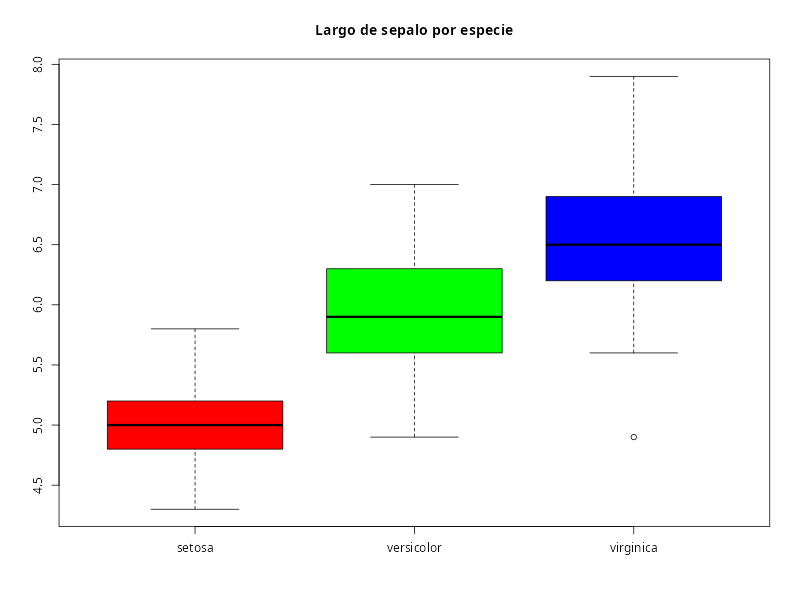

In [10]:
# Gráfico de caja para el largo del sépalo por especie
boxplot(iris$Sepal.Length ~ iris$Species, col=c("red", "green", "blue"), main= "Largo de sepalo por especie",xlab=" ",ylab=" ")

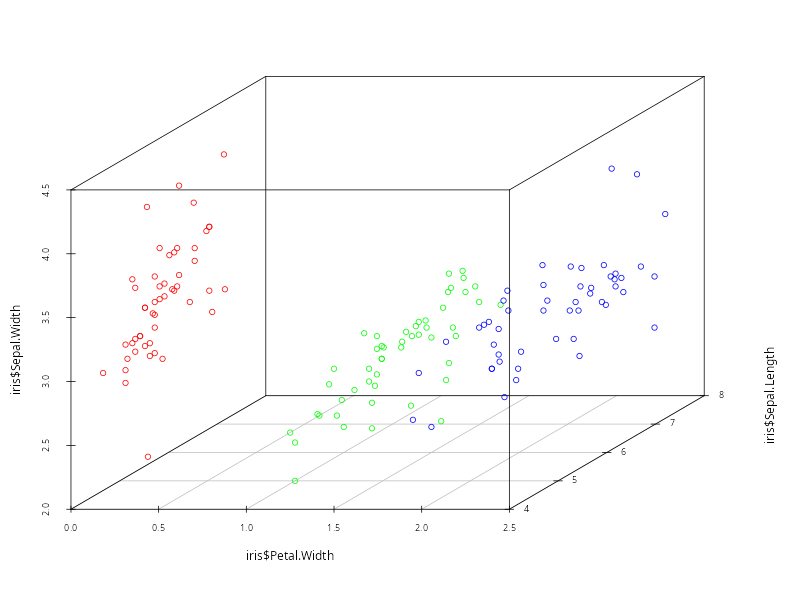

In [11]:
library(scatterplot3d)
# Gráfico de dispersión 3D entre el ancho del pétalo, el largo del sépalo y el ancho del sépalo, coloreando por especie
scatterplot3d(iris$Petal.Width, iris$Sepal.Length, iris$Sepal.Width, color=c("red", "green", "blue")[unclass(iris[,5])])

## PCA   

Realizamos el análisis de componentes principales (PCA) sobre las variables numéricas del dataset, escalando los datos para que tengan media 0 y desviación estándar 1.

In [12]:
iris.pca <- prcomp(iris[-5], scale=T) 
iris.pca

Standard deviations (1, .., p=4):
[1] 1.7083611 0.9560494 0.3830886 0.1439265

Rotation (n x k) = (4 x 4):
                    PC1         PC2        PC3        PC4
Sepal.Length  0.5210659 -0.37741762  0.7195664  0.2612863
Sepal.Width  -0.2693474 -0.92329566 -0.2443818 -0.1235096
Petal.Length  0.5804131 -0.02449161 -0.1421264 -0.8014492
Petal.Width   0.5648565 -0.06694199 -0.6342727  0.5235971

In [13]:
summary(iris.pca)

Importance of components:
                          PC1    PC2     PC3     PC4
Standard deviation     1.7084 0.9560 0.38309 0.14393
Proportion of Variance 0.7296 0.2285 0.03669 0.00518
Cumulative Proportion  0.7296 0.9581 0.99482 1.00000

In [14]:
# Proporción de varianza explicada por cada componente principal
prop_varianza <- iris.pca$sdev^2 / sum(iris.pca$sdev^2)
prop_varianza_acum <- cumsum(prop_varianza)
prop_varianza_acum

[1] 0.7296245 0.9581321 0.9948213 1.0000000

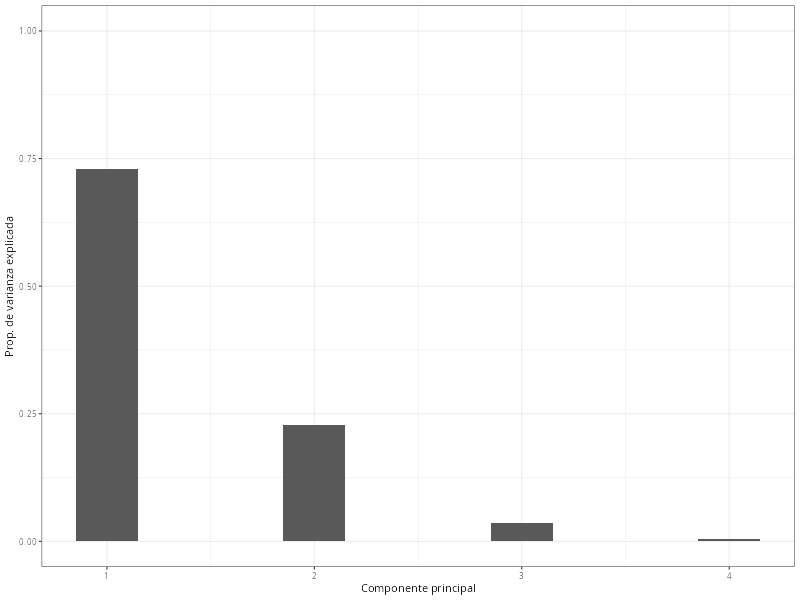

In [15]:
ggplot(data = data.frame(prop_varianza, pc = 1:4),
       aes(x = pc, y = prop_varianza)) +
  geom_col(width = 0.3) +
  scale_y_continuous(limits = c(0,1)) +
  theme_bw() +
  labs(x = "Componente principal",
       y = "Prop. de varianza explicada")

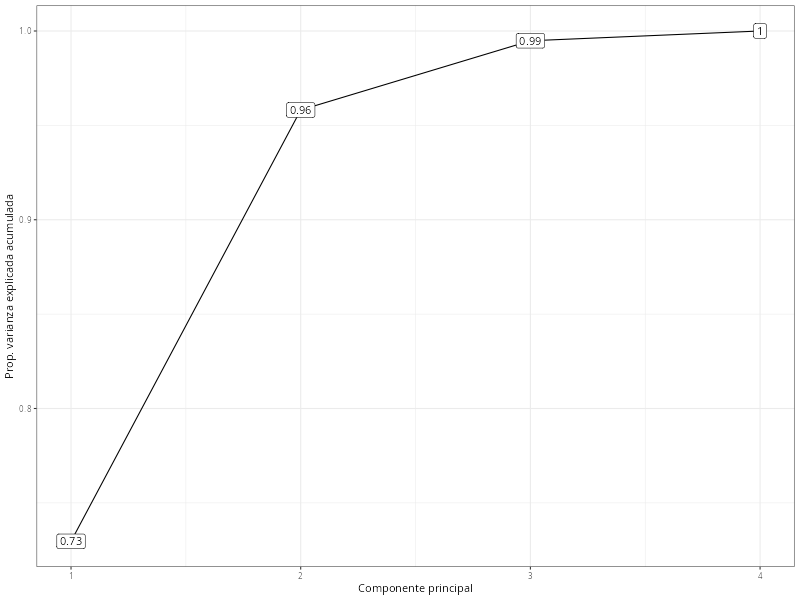

In [16]:
ggplot(data = data.frame(prop_varianza_acum, pc = 1:4),
       aes(x = pc, y = prop_varianza_acum, group = 1)) +
  geom_point() +
  geom_line() +
  geom_label(aes(label = round(prop_varianza_acum,2))) +
  theme_bw() +
  labs(x = "Componente principal",
       y = "Prop. varianza explicada acumulada")

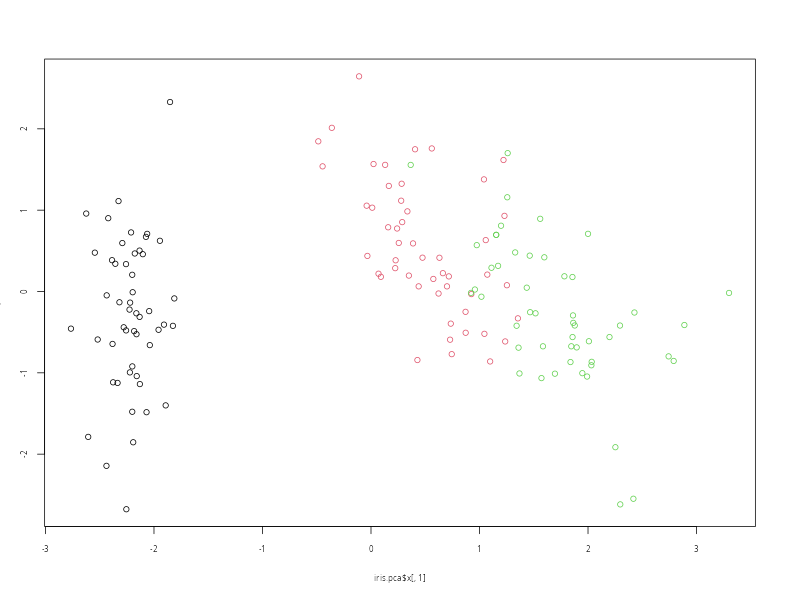

In [17]:
grupos<-iris$Species
plot(iris.pca$x[,1],iris.pca$x[,2],
     col=grupos,cex.axis=.7,cex.lab=.7)

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


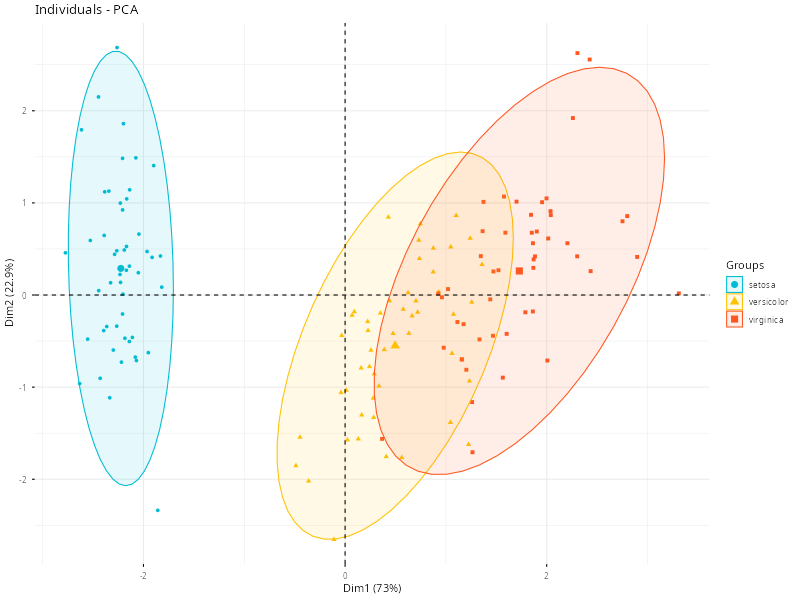

Ignoring unknown labels:
• linetype : "Groups"

In [ ]:
library("FactoMineR")
library("factoextra")

# Realizamos el análisis de componentes principales (PCA) con FactoMineR y visualizamos los individuos con factoextra, coloreando por especie y añadiendo elipses de confianza al 95%
res.pca <- PCA(iris[,-5], graph = FALSE)

fviz_pca_ind(res.pca,
             habillage = iris$Species,    # colorea por especie
             addEllipses = TRUE,          # añade las elipses
             ellipse.level = 0.95,        # nivel de confianza 95%
             palette = c("#00BCD4", "#FFC107", "#FF5722"),  # azul, amarillo, naranja
             geom.ind = "point",          # solo puntos (sin etiquetas numéricas)
             mean.point = TRUE,           # muestra el centroide de cada grupo
             legend.title = "Groups")